# PANDAS /

A Pandas Series is a 1-dimensional labeled array that can store any type of data (integers, floats, strings, booleans, etc.).

In [3]:
# import pandas as pd
# s = pd.Series(data)

In [6]:
import pandas as pd
numbers = [10, 20, 30, 40, 50]
s = pd.Series(numbers)

print(s)

0    10
1    20
2    30
3    40
4    50
dtype: int64


In [ ]:
s = pd.Series([90, 85, 78], index=["Math", "Science", "English"])
print(s)

Math       90
Science    85
English    78
dtype: int64


In [9]:
a = pd.Series([19, 20, 21, 22], name=["PIYUSH, ANKITA , DAMROO, USTAAD"])
print(a)

TypeError: Series.name must be a hashable type

In [10]:
a = pd.Series(
    [19, 20, 21, 22],
    index=["PIYUSH", "ANKITA", "DAMROO", "USTAAD"]
)

In [11]:
a

PIYUSH    19
ANKITA    20
DAMROO    21
USTAAD    22
dtype: int64

## missing data 

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

df = pd.DataFrame({
    'age': np.random.randint(18, 60, n).astype(float),
    'income': np.random.randint(20000, 100000, n).astype(float),
    'city': np.random.choice(['Delhi', 'Mumbai', 'Pune', 'Chennai'], n),
    'purchased': np.random.choice([0, 1], n),
    'signup_date': pd.date_range('2023-01-01', periods=n, freq='D')
})

# Inject missing values artificially (to simulate real-world data)
df.loc[df.sample(frac=0.15, random_state=1).index, 'age'] = np.nan
df.loc[df.sample(frac=0.25, random_state=2).index, 'income'] = np.nan
df.loc[df.sample(frac=0.05, random_state=3).index, 'city'] = np.nan

# Make income missing depend on 'purchased' (simulate MAR)
df.loc[df['purchased'] == 0, 'income'] = df.loc[df['purchased'] == 0, 'income'].mask(
    np.random.rand((df['purchased'] == 0).sum()) < 0.3
)

In [2]:
df.info()          # shows non-null counts per column
df.describe()       # only summarizes non-missing numeric data
df.isnull().sum()   # missing count per column

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   age          170 non-null    float64       
 1   income       121 non-null    float64       
 2   city         190 non-null    str           
 3   purchased    200 non-null    int64         
 4   signup_date  200 non-null    datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), str(1)
memory usage: 7.9 KB


age            30
income         79
city           10
purchased       0
signup_date     0
dtype: int64

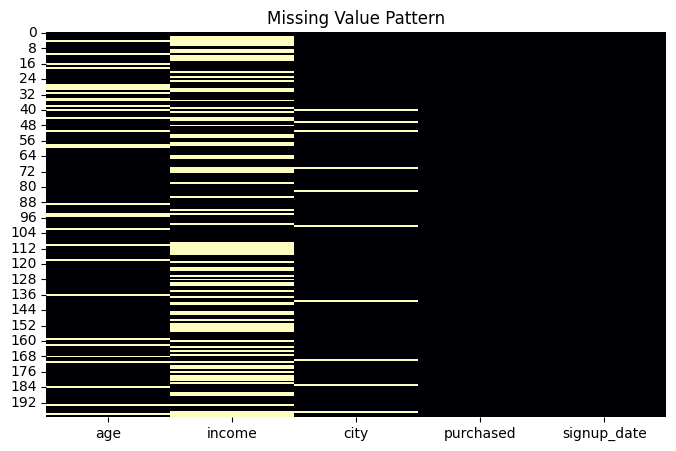

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='magma')
plt.title("Missing Value Pattern")
plt.show()

In [5]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'dtype': df.dtypes
}).sort_values('missing_pct', ascending=False)

print(missing_summary)

             missing_count  missing_pct           dtype
income                  79         39.5         float64
age                     30         15.0         float64
city                    10          5.0             str
purchased                0          0.0           int64
signup_date              0          0.0  datetime64[us]


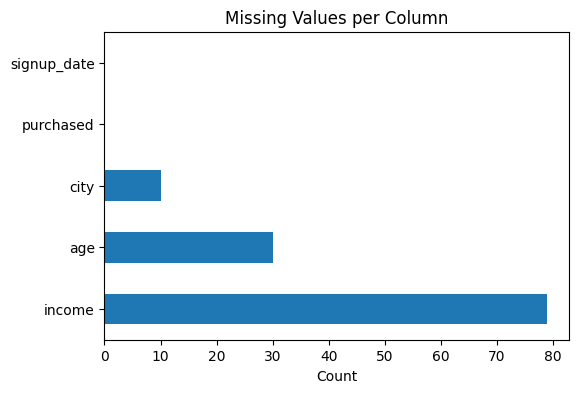

In [6]:
missing_summary['missing_count'].plot(kind='barh', figsize=(6,4))
plt.title("Missing Values per Column")
plt.xlabel("Count")
plt.show()

In [2]:
import pandas as pd 
s = pd.Series([10,20,30], index=['a','b','c'])
df = pd.DataFrame({ 'Name': ['Amit','Riya','Karan'], 'Age': [25,30,22], 'City': ['Delhi','Mumbai','Pune']})
df.head()
df.info()
df.describe() # statistical summary (mean, std, min, max)

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Name    3 non-null      str  
 1   Age     3 non-null      int64
 2   City    3 non-null      str  
dtypes: int64(1), str(2)
memory usage: 204.0 bytes


,Age
count,3.000000
mean,25.666667
std,4.041452
min,22.000000
25%,23.500000
50%,25.000000
75%,27.500000
max,30.000000


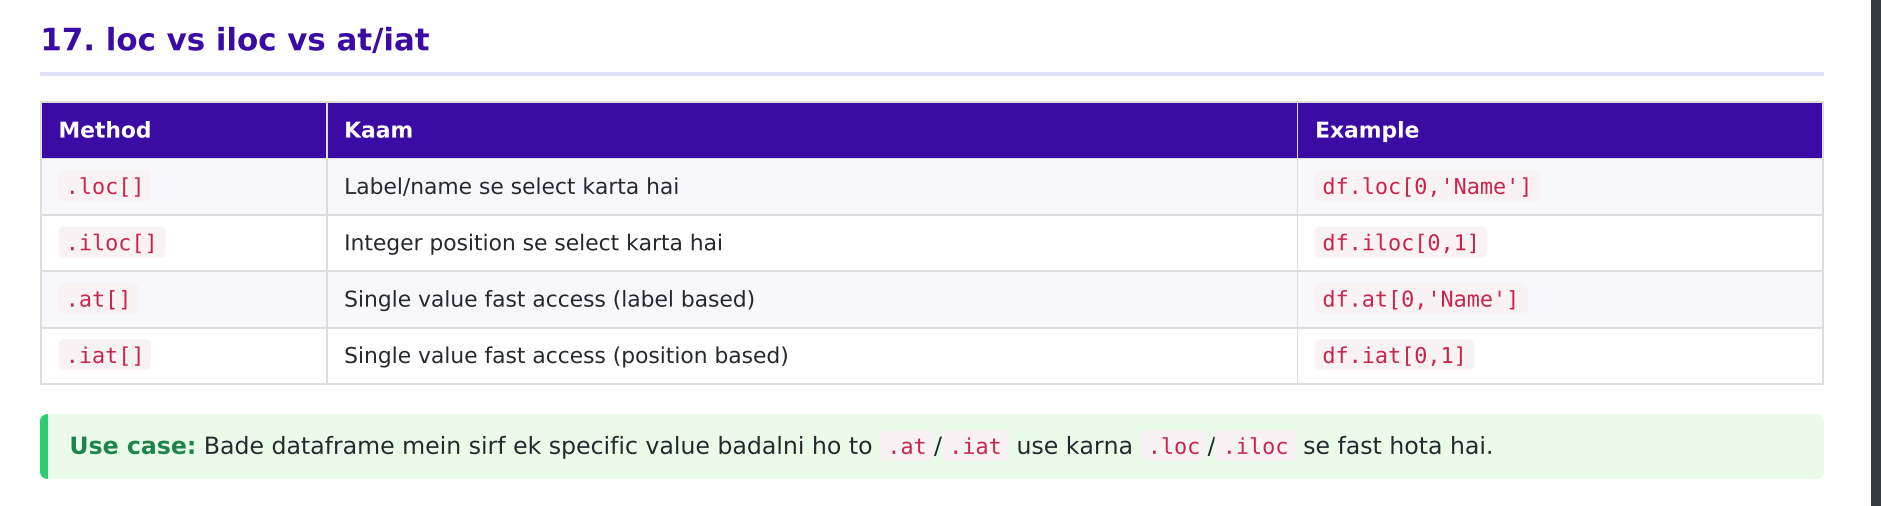